In [1]:
import numpy as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np
import gc
import matplotlib.pyplot as plt

from tsfresh import (
    extract_features,  
    select_features
)
from tsfresh.utilities.dataframe_functions import impute

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

import numpy as np
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from tsfresh.feature_extraction.settings import from_columns

In [45]:
file_prefix = "dataExt/P"
file_suffix = "_energy.pkl"
num_files = 35

all_x = np.concatenate(
    [np.load(f"{file_prefix}{i:02d}{file_suffix}", allow_pickle=True) for i in range(num_files)],
    axis=0
)


In [46]:
# Load and concatenate all features
file_prefix = "dataExt/P"
file_suffix = "_intensity.pkl"
num_files = 35

all_y = np.concatenate(
    [np.load(f"{file_prefix}{i:02d}{file_suffix}", allow_pickle=True) for i in range(num_files)],
    axis=0
)

label_arr = np.array([np.tile(i,np.load(f"{file_prefix}{0:02d}{file_suffix}", allow_pickle=True).shape[0]) for i in np.arange(num_files)]).flatten()
gc.collect()

483

In [ ]:
n_samples = all_y.shape[0]

In [54]:
def extract_feature_list_from_subset(features_intensity, features_energies):

    data_df = pd.DataFrame()
    labels_df = pd.Series()

    subsample_inx = 1000
    subset_intensities = features_intensity[::subsample_inx]
    subset_energies = features_energies[::subsample_inx]

    data_df['id'] = np.repeat(np.arange(subset_intensities.shape[0]),subset_intensities.shape[1])
    data_df['time'] = np.tile(np.arange(subset_intensities.shape[1]), subset_intensities.shape[0])
    data_df['energy'] = subset_intensities.flatten()
    data_df['intensity'] = subset_energies.flatten()
    data_df.to_parquet('dataExt/subsample_data_df.parquet')

    labels_df['labels'] = label_arr[::subsample_inx]

    # Load data once
    dask_df = dd.read_parquet('dataExt/subsample_data_df.parquet', npartitions=10)

    # Extract features
    extracted_features = extract_features(dask_df, column_id="id", column_sort="time",n_jobs=-1, disable_progressbar=False).compute()

    # Handle any NaNs
    impute(extracted_features)

    # Convert labels to a Series (ensure it’s 1D if needed)
    labels_series =  pd.Series(np.array(labels_df.to_numpy()[0]))

    # Select relevant features
    features_filtered = select_features(extracted_features, labels_series, multiclass=True, fdr_level=0.05)

    kind_to_fc_parameters = from_columns(features_filtered)

    gc.collect()

    return kind_to_fc_parameters, features_filtered.shape[1], features_filtered

kind_to_fc_parameters, n_features, features_filtered = extract_feature_list_from_subset(all_x, all_y)

In [ ]:
def extract_features_from_full(features_intensity, features_energies, kind_to_fc_parameters, n_samples, n_features):
    
        
    data_df = pd.DataFrame()
    labels_df = pd.Series()

    subset_intensities = features_intensity
    subset_energies = features_energies

    data_df['id'] = np.repeat(np.arange(subset_intensities.shape[0]),subset_intensities.shape[1])
    data_df['time'] = np.tile(np.arange(subset_intensities.shape[1]), subset_intensities.shape[0])
    data_df['energy'] = subset_intensities.flatten()
    data_df['intensity'] = subset_energies.flatten()
    data_df.to_parquet('dataExt/data_df.parquet')

    labels_df['labels'] = label_arr


    # Load data once
    dask_df = dd.read_parquet('dataExt/data_df.parquet', npartitions=15)

    X = extract_features(dask_df,
                        column_id="id",
                        column_sort="time",
                        pivot=False,
                        kind_to_fc_parameters=kind_to_fc_parameters,
                        disable_progressbar=False
                        )

    result = X.compute()

    np.save("dataExt/features_filtered.npy", np.reshape(result["value"].to_numpy(), (n_samples, n_features)))

In [12]:
# Later, load the saved array in memory-mapped mode
features_memmap = np.load('dataExt/features_filtered.npy', mmap_mode='r+')

### tune hyperparameters

In [ ]:
# Train-test split
X_train_old, X_test_old, y_train, y_test = train_test_split(all_features[::100], label_arr, test_size=0.1, random_state=42)
X_train_new, X_test_new, _, _ = train_test_split(features_filtered, label_arr, test_size=0.1, random_state=42)

In [ ]:
# Define the model
model = HistGradientBoostingClassifier()

# Define the parameter grid with a large search space
param_grid = {
    'learning_rate': np.logspace(-3, 0, 10),     # Learning rates between 0.001 and 1
    'max_iter': [50, 100, 200, 300],             # Number of boosting iterations
    'max_leaf_nodes': [10, 20, 31, 50, 100],     # Number of leaves in trees
    'min_samples_leaf': [10, 20, 30, 50, 100],   # Minimum samples per leaf
    'l2_regularization': np.logspace(-3, 1, 5)   # Regularization strength
}

# Define the halving search with cross-validation
halving_search = HalvingRandomSearchCV(
    estimator=model,
    param_distributions=param_grid,
    factor=2,                       # Halving factor (reduces candidate space by half each iteration)
    cv=5,                           # 5-fold cross-validation
    scoring='accuracy',
    random_state=42,
    n_jobs=1,                       # Use all available CPU cores,
    verbose = 1
)

# Perform the halving search
halving_search.fit(X_train_new, y_train)

# Print the best parameters and score
print("Best parameters found: ", halving_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(halving_search.best_score_))

# Evaluate the best model on the test set
best_model = halving_search.best_estimator_
test_accuracy = accuracy_score(y_test, best_model.predict(X_test_new))
print("Test accuracy: {:.2f}".format(test_accuracy))


n_iterations: 9
n_required_iterations: 9
n_possible_iterations: 9
min_resources_: 80
max_resources_: 21600
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 270
n_resources: 80
Fitting 5 folds for each of 270 candidates, totalling 1350 fits


/home/felix/vscodeProjects/pole-learning/.venv_pole/lib/python3.11/site-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


----------
iter: 1
n_candidates: 135
n_resources: 160
Fitting 5 folds for each of 135 candidates, totalling 675 fits


/home/felix/vscodeProjects/pole-learning/.venv_pole/lib/python3.11/site-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


----------
iter: 2
n_candidates: 68
n_resources: 320
Fitting 5 folds for each of 68 candidates, totalling 340 fits
----------
iter: 3
n_candidates: 34
n_resources: 640
Fitting 5 folds for each of 34 candidates, totalling 170 fits


...

----------
iter: 7
n_candidates: 3
n_resources: 10240
Fitting 5 folds for each of 3 candidates, totalling 15 fits


/home/felix/vscodeProjects/pole-learning/.venv_pole/lib/python3.11/site-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


----------
iter: 8
n_candidates: 2
n_resources: 20480
Fitting 5 folds for each of 2 candidates, totalling 10 fits


/home/felix/vscodeProjects/pole-learning/.venv_pole/lib/python3.11/site-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters found:  {'min_samples_leaf': 20, 'max_leaf_nodes': 50, 'max_iter': 300, 'learning_rate': np.float64(0.1), 'l2_regularization': np.float64(0.001)}
Best cross-validation accuracy: 0.93
Test accuracy: 0.94


In [ ]:
# Initialize the model
model_old = HistGradientBoostingClassifier(random_state=42)
model_new = HistGradientBoostingClassifier(**{'min_samples_leaf': 20, 'max_leaf_nodes': 50, 'max_iter': 300, 'learning_rate': np.float64(0.1), 'l2_regularization': np.float64(0.001),'random_state':42})


cv_old = cross_validate(model_old, X_train_old, y_train, cv=5, scoring='accuracy', return_estimator=True)
cv_new = cross_validate(model_new, X_train_new, y_train, cv=5, scoring='accuracy', return_estimator=True)

In [ ]:
rmse = cv_old["test_score"]
print(f"Validation Accuracy Old Data = {rmse.mean():.3f} +/- {rmse.std():.3f}")

rmse = cv_new["test_score"]
print(f"Validation Accuracy New Data = {rmse.mean():.3f} +/- {rmse.std():.3f}")

Validation Accuracy Old Data = 0.650 +/- 0.012
Validation Accuracy New Data = 0.751 +/- 0.010


In [ ]:
old_test_arr = np.zeros(5)
new_test_arr = np.zeros(5)

for cnt,est in enumerate(cv_old["estimator"]):
    old_test_arr[cnt] = accuracy_score(y_test, est.predict(X_test_old))

for cnt,est in enumerate(cv_new["estimator"]):
    new_test_arr[cnt] = accuracy_score(y_test, est.predict(X_test_new))

print(f"Old Dataset - Test Accuracy: {np.mean(old_test_arr):.4f} ± {np.std(old_test_arr):.4f}")
print(f"New Dataset - Test Accuracy: {np.mean(new_test_arr):.4f} ± {np.std(new_test_arr):.4f}")

Old Dataset - Test Accuracy: 0.6554 ± 0.0165
New Dataset - Test Accuracy: 0.7086 ± 0.0094


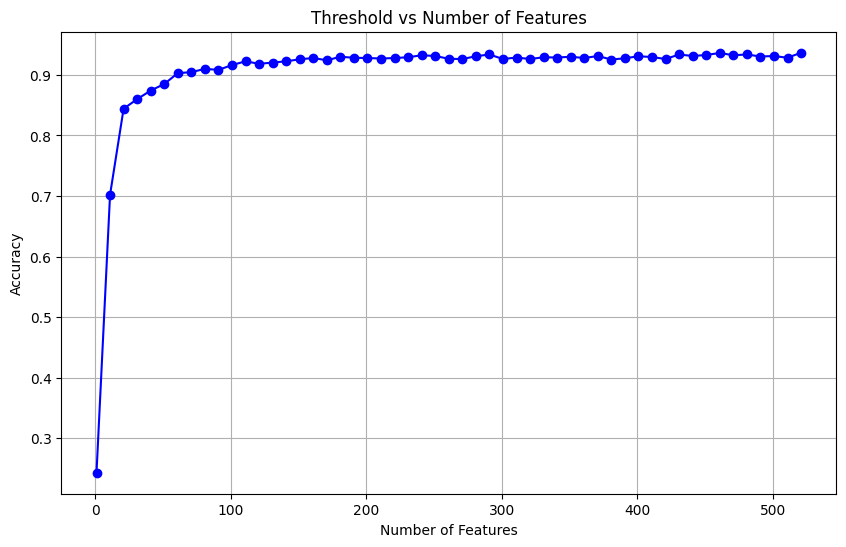

Best Threshold: 521.0000
Best Accuracy: 0.9367
Number of Features: 521


In [ ]:

# Define a range of thresholds to test
thresholds = np.arange(1, X_train_new.shape[1], 10)  # 50 thresholds between 0 and 0.5
accuracies = []
num_features_list = []

best_accuracy = 0
best_threshold = 0
best_num_features = X_train_new.shape[1]

for threshold in thresholds:
    selector = SelectKBest(f_classif, k=int(threshold))
    X_train_selected = selector.fit_transform(X_train_new, y_train)
    X_test_selected = selector.transform(X_test_new)
    
    # Initialize and fit a HistGradientBoostingClassifier with isotonic calibration
    hgb_classifier = HistGradientBoostingClassifier(random_state=42)
    hgb_classifier.fit(X_train_selected, y_train)
    
    # Evaluate accuracy
    y_pred = hgb_classifier.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Keep track of accuracy and number of features
    num_features = X_train_selected.shape[1]
    accuracies.append(accuracy)
    num_features_list.append(num_features)
    
    # Keep track of the best threshold based on accuracy and feature count
    if accuracy > best_accuracy or (accuracy == best_accuracy and num_features < best_num_features):
        best_accuracy = accuracy
        best_threshold = threshold
        best_num_features = num_features

# Plot threshold vs number of features
plt.figure(figsize=(10, 6))
plt.plot(num_features_list, accuracies, label="Number of Features", color='blue', marker='o')
plt.ylabel("Accuracy")
plt.xlabel("Number of Features")
plt.title("Threshold vs Number of Features")
plt.grid(True)

plt.show()

# Print the best threshold and accuracy information
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print(f"Number of Features: {best_num_features}")


In [ ]:
# Number of classes
num_classes = 8

# Calculate accuracy for each class
class_accuracies = []
for cls in range(num_classes):
    # Mask for the current class
    class_mask = (y_test == cls)
    # Calculate accuracy: number of correct predictions for class `cls` / total number of instances of class `cls`
    class_accuracy = np.sum(best_model.predict(X_test_new)[class_mask] == y_test[class_mask]) / np.sum(class_mask)
    class_accuracies.append(class_accuracy)

# Convert to numpy array for plotting
class_accuracies = np.array(class_accuracies)

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(range(num_classes), class_accuracies, color='skyblue')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.xticks(range(num_classes), [f'Class {i}' for i in range(num_classes)])
plt.ylim(0, 1)  # Accuracy goes from 0 to 1
plt.show()

NameError: name 'best_model' is not defined

(array([  0.,   0.,   0.,   0.,   0., 314.,   0.,   0.,   0.,   0.]),
 array([6.5, 6.6, 6.7, 6.8, 6.9, 7. , 7.1, 7.2, 7.3, 7.4, 7.5]),
 <BarContainer object of 10 artists>)

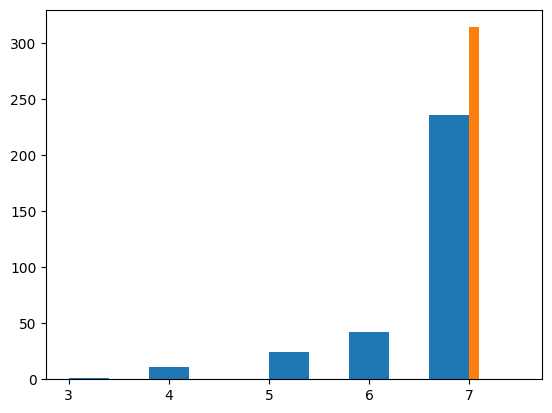

In [ ]:
class_mask = (y_test == 7)
plt.hist(best_model.predict(X_test_new)[class_mask])  
plt.hist(y_test[class_mask])